<a href="https://colab.research.google.com/github/jfpa11100/E-Sports-ML/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto 1: E-Sports Biometrics & Performance**
## Predicción del resultado de partidas (Win/Loss) a partir de biométricas y métricas ambientales de jugadores de e-sports

**Curso:** Inteligencia Artificial

**Universidad:** Universidad de Medellín (UdeM)

**Profesor:** Antonio Jesús Tamayo Herrera

**Semestre:** 2026-1

**Integrantes:**
- Mariana Pineda Isaza
- Juan Pablo Ramírez
- Juan Felipe Palacio

---

### **Descripción del proyecto**

Este proyecto utiliza el dataset **[E-Sports Biometrics & Performance](https://www.kaggle.com/datasets/sarveshchhetri/e-sports-biometrics-and-performance)** de Kaggle, un conjunto de datos sintético de 250,000 registros diseñado para simular factores fisiológicos y ambientales reales que afectan a atletas de e-sports (élite y casuales).

El dataset mide cómo métricas biológicas como el ritmo cardíaco, la fatiga y el sueño impactan el rendimiento dentro del juego y el resultado de las partidas, un tema relevante para la ciencia del deporte aplicada a los e-sports, un campo en crecimiento junto con la industria.

**Problema:** Clasificación binaria — predecir la variable `Match_Outcome` (Win / Loss) a partir del estado biológico y ambiental de un jugador previo a la partida (edad, horas de sueño, energizantes consumidos, brillo de pantalla, ritmo cardíaco, HRV, APM, tiempo de reacción, entre otras).

### **Descripción del dataset:**

| Column_Name       | Description                                                                                                                                       |
|-------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| Player_ID         | Un identificador alfanumérico único para cada jugador.                                                                                            |
| Age               | La edad del jugador, entre 16 y 40 años.                                                                                                          |
| Game_Genre        | La categoría del juego jugado durante la sesión (MOBA, FPS, Battle Royale o Fighting).                                                           |
| PlayTime_Hours    | La duración de la sesión de juego actual en horas, utilizada para medir la fatiga.                                                                |
| Sleep_Hours       | El número de horas que durmió el jugador la noche anterior a la sesión.                                                                          |
| Energy_Drinks     | El número de bebidas energéticas (con cafeína) consumidas antes o durante la partida.                                                            |
| Screen_Brightness | El nivel de brillo del monitor del jugador expresado como porcentaje (contiene aproximadamente un 5 % de valores faltantes).                   |
| Blue_Light_Filter | Indica si había un filtro de luz azul activo en la pantalla (Sí / No).                                                                            |
| APM               | Acciones por minuto. Una medida de cuántas acciones (clics/pulsaciones de teclas) realiza el jugador por minuto.                                |
| Heart_Rate_BPM    | La frecuencia cardíaca promedio del jugador, en latidos por minuto, durante la partida.                                                          |
| HRV_Score         | Puntuación de variabilidad de la frecuencia cardíaca (10-100). Las puntuaciones más altas generalmente indican menor estrés fisiológico y mejor recuperación (contiene aproximadamente un 2 % de valores faltantes). |
| Reaction_Time_ms  | El tiempo de reacción promedio del jugador medido en milisegundos (ms).                                                                           |
| Match_Outcome     | El resultado final de la partida (Victoria / Derrota).                                                                                           |

### **Tipo de cada variable:**

- **Numéricas:** `Age`, `PlayTime_Hours`, `Sleep_Hours`, `Energy_Drinks`, `Screen_Brightness`, `APM`, `Heart_Rate_BPM`, `HRV_Score`, `Reaction_Time_ms`
- **Categórica nominal:** `Game_Genre` (4 categorías: MOBA, FPS, Battle Royale, Fighting)
- **Binarias:** `Blue_Light_Filter` (Yes/No), `Match_Outcome` (Win/Loss — variable objetivo)
- **Identificador (se descarta):** `Player_ID`

## **Análisis exploratorio de datos (EDA)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [ ]:
import os
import pandas as pd

dataset_url = 'https://raw.githubusercontent.com/jfpa11100/E-Sports-ML/main/data/esports_gaming_biometrics_250k.csv'

try:
    df = pd.read_csv(dataset_url)
    print("Dataset cargado exitosamente desde GitHub.")
    display(df.head(9))
except Exception as e:
    print(f"Error al cargar el dataset desde GitHub: {e}")
    df = pd.DataFrame()

Dataset cargado exitosamente desde GitHub.


,Player_ID,Age,Game_Genre,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,Blue_Light_Filter,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms,Match_Outcome
0,PL_000001,24,FPS,1.41,8.88,0,43.4,Yes,107,78,95.02,268.96,Loss
1,PL_000002,22,FPS,4.43,7.45,2,88.0,Yes,110,102,82.92,281.90,Win
2,PL_000003,25,Battle Royale,3.75,8.10,1,24.8,Yes,152,96,89.13,288.57,Win
3,PL_000004,29,FPS,1.76,6.69,0,80.2,No,151,65,80.41,279.76,Win
4,PL_000005,22,FPS,5.79,8.17,1,34.4,No,148,95,95.71,229.62,Loss
5,PL_000006,22,MOBA,0.50,5.81,1,22.1,No,233,84,100.00,264.14,Loss
6,PL_000007,29,FPS,0.84,7.46,0,73.0,No,125,71,97.34,278.56,Loss
7,PL_000008,26,Battle Royale,1.41,6.08,0,34.5,No,110,68,88.56,272.00,Loss
8,PL_000009,21,FPS,3.89,5.92,1,14.0,Yes,148,76,90.07,263.71,Loss


In [ ]:
# Eliminamos el Player ID ya que no aporta al modelo
df = df.drop(columns=['Player_ID'], errors='ignore')

print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [ ]:
df.describe()

,Age,PlayTime_Hours,Sleep_Hours,Energy_Drinks,Screen_Brightness,APM,Heart_Rate_BPM,HRV_Score,Reaction_Time_ms
count,250000.000000,250000.000000,250000.000000,250000.000000,237452.000000,250000.000000,250000.000000,245066.000000,250000.000000
mean,22.588136,2.527753,6.500900,0.917720,54.918735,204.076168,84.062784,87.479087,262.900538
std,3.829706,2.358799,1.495851,1.045559,25.965989,77.004233,9.670229,11.063101,19.096927
min,16.000000,0.500000,2.000000,0.000000,10.000000,30.000000,60.000000,25.510000,175.170000
25%,20.000000,0.720000,5.490000,0.000000,32.500000,143.000000,77.000000,80.590000,249.930000
50%,23.000000,1.730000,6.500000,1.000000,54.900000,192.000000,84.000000,89.190000,262.590000
75%,25.000000,3.470000,7.510000,1.000000,77.400000,263.000000,90.000000,97.260000,275.600000
max,40.000000,12.000000,11.000000,4.000000,100.000000,563.000000,129.000000,100.000000,355.470000


In [ ]:
print("Rango de Age:", df['Age'].min(), "-", df['Age'].max())
print("Rango de Sleep_Hours:", df['Sleep_Hours'].min(), "-", df['Sleep_Hours'].max())
print("Rango de HRV_Score:", df['HRV_Score'].min(), "-", df['HRV_Score'].max())

Rango de Age: 16 - 40
Rango de Sleep_Hours: 2.0 - 11.0
Rango de HRV_Score: 25.51 - 100.0


### **Balance de la variable de salida**

In [ ]:
df['Match_Outcome'].value_counts(normalize=True)

,proportion
Match_Outcome,
Loss,0.519376
Win,0.480624


**Análisis:** La variable de salida está prácticamente balanceada: **51.9% Loss / 48.1% Win**. Esto es
importante porque significa que no necesitamos técnicas de balanceo ni preocuparnos de que el accuracy sea engañosa por desbalance.

### **Distribuciones de las variables categóricas**

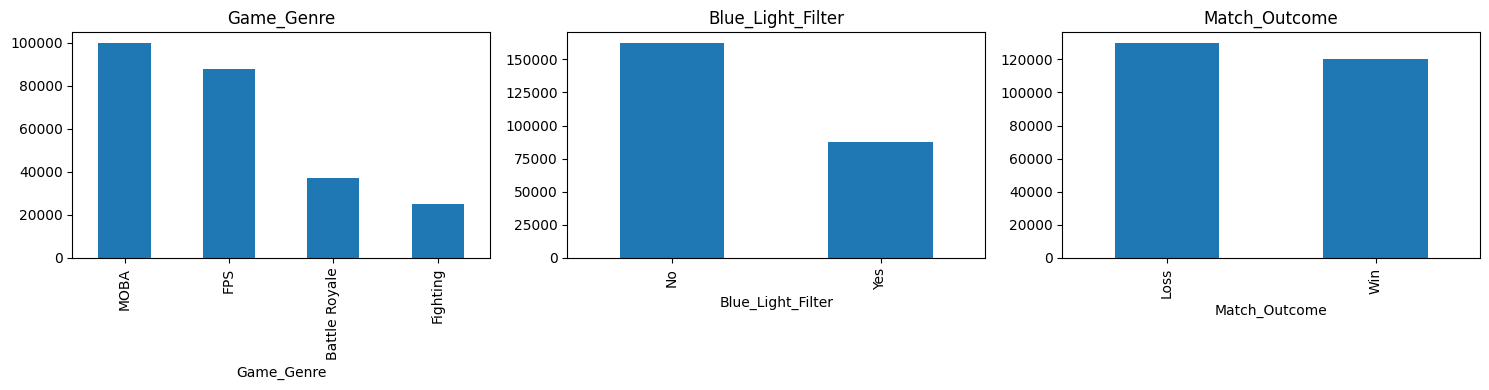

In [ ]:
import matplotlib.pyplot as plt

cat_cols = ['Game_Genre', 'Blue_Light_Filter', 'Match_Outcome']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Análisis:** `Game_Genre` no está balanceado entre sus 4 categorías: MOBA y FPS dominan, mientras que Battle Royale y Fighting están mucho menos representadas. Esto no es un problema para el modelo, pero significa que las predicciones para esas dos categorías se apoyan en menos ejemplos `Blue_Light_Filter` está aproximadamente 65% No / 35% Yes. `Match_Outcome` confirma el balance casi 50/50 visto arriba.

### **Distribuciones de las variables numéricas**

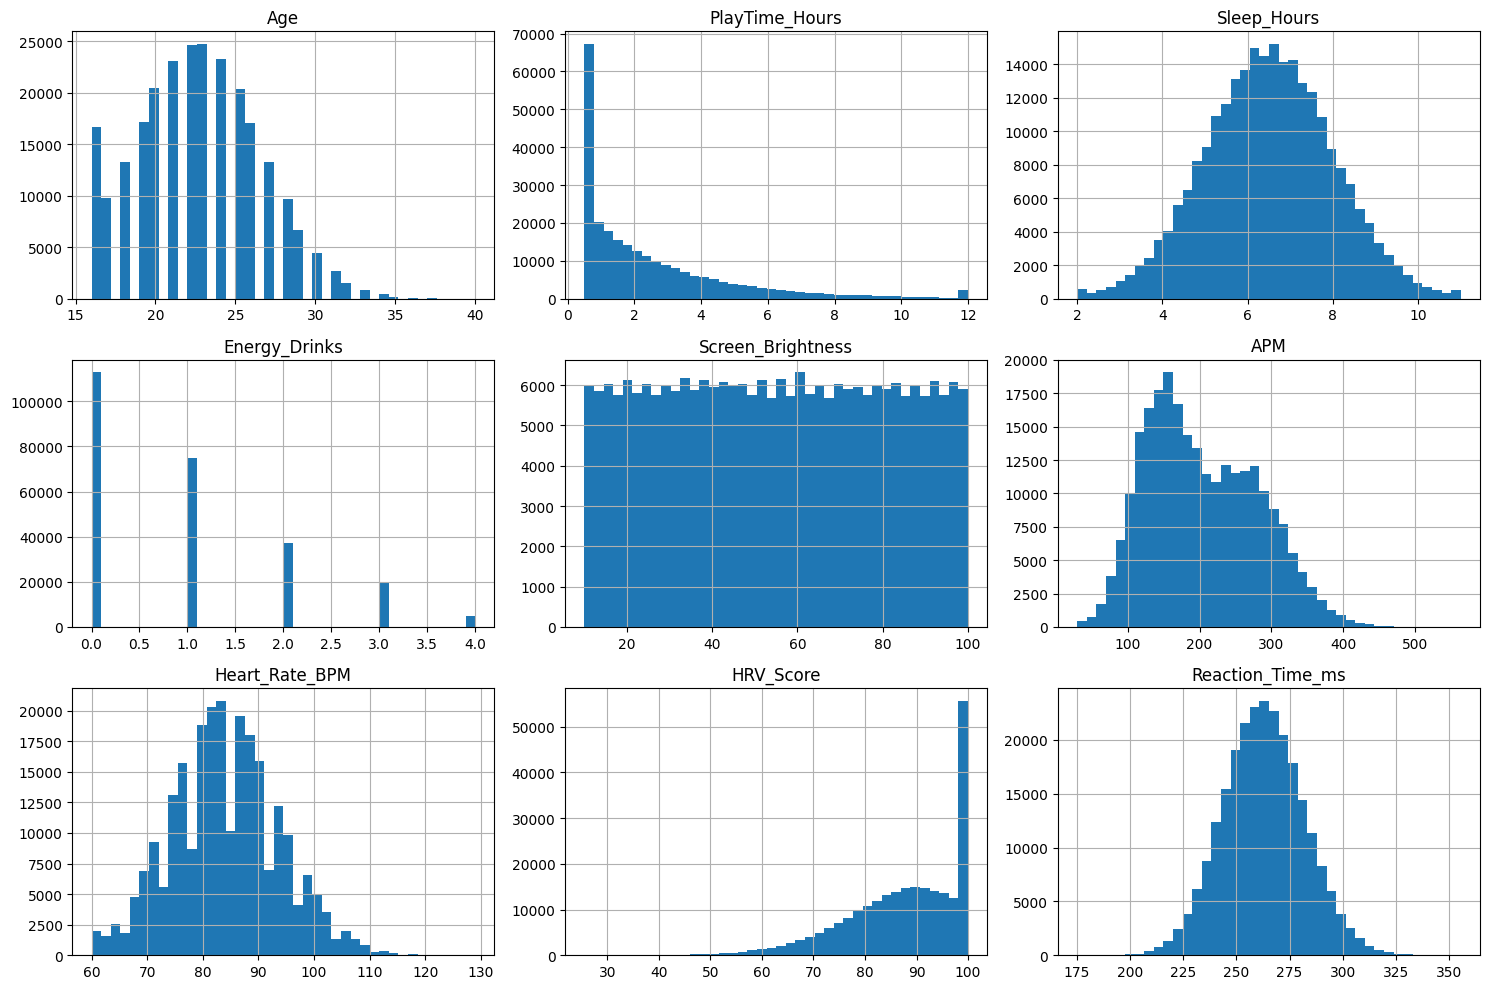

In [ ]:
num_cols = ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks',
            'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score', 'Reaction_Time_ms']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    df[col].hist(bins=40, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Análisis:** las variables numéricas tienen formas muy distintas entre sí, lo que confirma la necesidad de escalar antes de entrenar (especialmente para SVM):
- `Sleep_Hours`, `Heart_Rate_BPM` y `Reaction_Time_ms` tienen forma aproximadamente normal/simétrica.
- `PlayTime_Hours` está fuertemente sesgada a la derecha (la mayoría de sesiones dura menos de 2 horas, con una cola larga hasta 12h), típico de tiempos de duración de eventos.
- `HRV_Score` está sesgada a la izquierda, con una acumulación notoria en el valor máximo, esto según lo consultado, se trata de *ceiling
  effect*.
- `Energy_Drinks` es una variable discreta (0 a 4 bebidas), con la mayoría de jugadores en 0 o 1.
- `Screen_Brightness` se ve prácticamente **uniforme** entre 10 y 100, consistente con ser un ajuste manual del
  usuario sin un valor "típico" preferido.
- `APM` tiene sesgo moderado a la derecha, con la mayoría de jugadores entre 100 y 300 acciones por minuto.

### **Relación de cada variable numérica con el resultado de la partida**

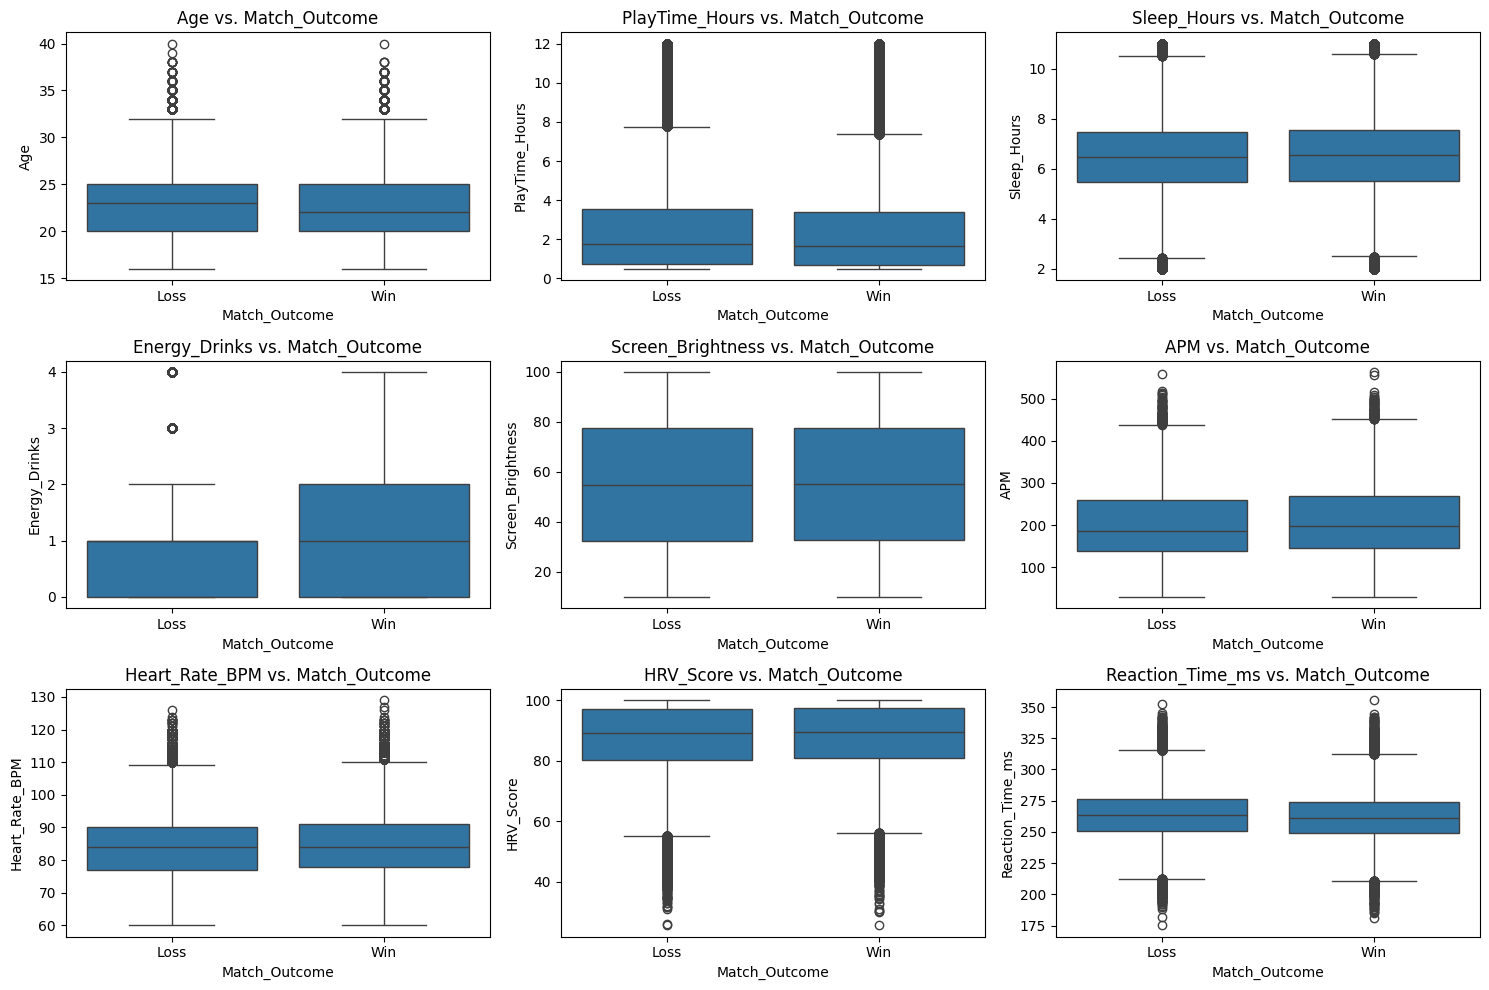

Promedio según el resultado:
Match_Outcome            Loss         Win
Age                 22.648440   22.522970
PlayTime_Hours       2.587483    2.463207
Sleep_Hours          6.474550    6.529374
Energy_Drinks        0.908583    0.927594
Screen_Brightness   54.842955   55.000619
APM                200.430963  208.015280
Heart_Rate_BPM      83.880541   84.259721
HRV_Score           87.288741   87.684773
Reaction_Time_ms   263.942624  261.774430


In [ ]:
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Match_Outcome', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs. Match_Outcome')
plt.tight_layout()
plt.show()

print("Promedio según el resultado:")
print(df.groupby('Match_Outcome')[num_cols].mean().T)

**Análisis:**

- Al comparar las cajas de Win vs. Loss en cada variable, se ven casi superpuestas, es decir, ninguna biométrica por sí sola permite distinguir claramente si un jugador va a ganar o perder.
- La diferencia más notoria entre clases está en **APM** (Win ≈ 208 vs. Loss ≈ 200, una diferencia de ≈7.5 unidades).
- En menor medida, también se ve en `Reaction_Time_ms` (Win ≈ 262 ms vs. Loss ≈ 264 ms) — los jugadores ganadores reaccionan levemente más rápido.
- El resto de variables (`Age`, `Sleep_Hours`, `Heart_Rate_BPM`, `HRV_Score`, `Screen_Brightness`, `Energy_Drinks`) muestran diferencias muy pequeñas entre clases.

**Conclusión preliminar:**
- `APM` parece ser la variable individual con mayor señal predictiva.
- El resto de biométricas, tomadas una por una, aportan poca separación.
- Es posible que el modelo dependa de **combinaciones** de variables (justo lo que la regresión logística y el SVM pueden capturar) más que de una sola variable dominante.

### **Relación de cada variable numérica con el resultado de la partida**

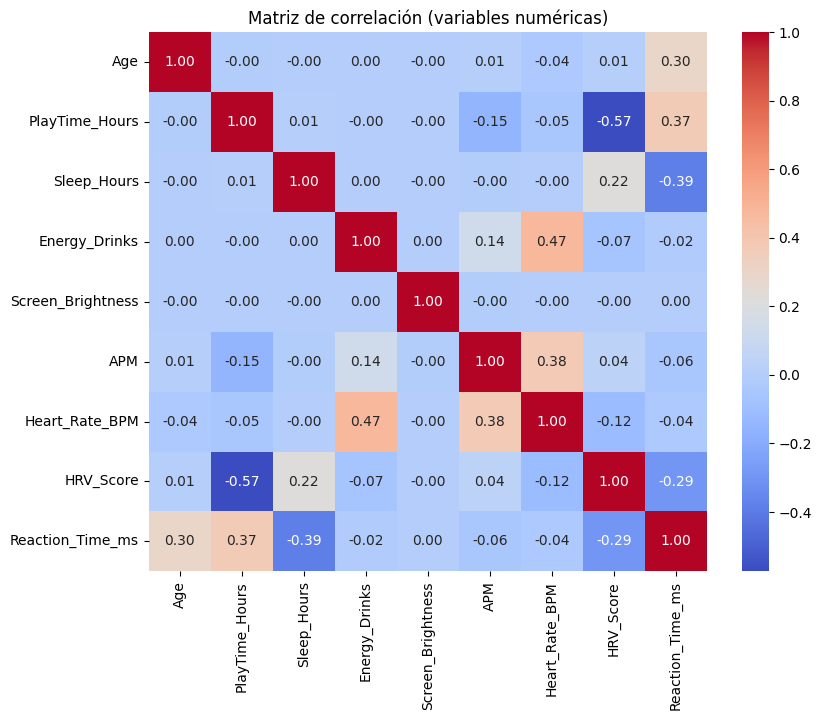

In [ ]:
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

**Análisis:** Ninguna correlación entre las variables predictoras supera ≈0.6 en valor absoluto, lo que indica que **no hay
multicolinealidad preocupante**, es decir, las variables no están tan relacionadas entre sí como para
distorsionar la interpretación de los coeficientes cuando entrenemos los modelos.

Las correlaciones más fuertes que sí aparecen tienen sentido fisiológico, lo cual es una buena señal de que el
dataset simula relaciones realistas y no ruido aleatorio:

- **Tiempo de juego y variabilidad cardíaca (`PlayTime_Hours` ↔ `HRV_Score`: -0.57):** a medida que un jugador
  lleva más tiempo jugando, su variabilidad cardíaca disminuye, esto se ve como un indicador típico de fatiga acumulada.
- **Energizantes y ritmo cardíaco (`Energy_Drinks` ↔ `Heart_Rate_BPM`: 0.47):** a más bebidas energéticas
  consumidas, mayor ritmo cardíaco, lo cual es el efecto estimulante esperado de la cafeína.
- **Actividad en el juego y ritmo cardíaco (`APM` ↔ `Heart_Rate_BPM`: 0.38):** los jugadores con más acciones
  por minuto también muestran un ritmo cardíaco más alto, reflejando mayor esfuerzo físico y mental.
- **Sueño y tiempo de reacción (`Sleep_Hours` ↔ `Reaction_Time_ms`: -0.39):** dormir más horas se asocia con
  reacciones más rápidas.
- **Fatiga, edad y tiempo de reacción (`PlayTime_Hours` ↔ `Reaction_Time_ms`: 0.37; `Age` ↔ `Reaction_Time_ms`:
  0.30):** tanto jugar por más tiempo como tener más edad se asocian con reacciones más lentas.

### **Tratamiento de valores faltantes**

Analizando los datos, obervamos que `Screen_Brightness` y `HRV_Score` son las únicas variables con datos faltantes. Antes de decidir entre imputar o
eliminar, comparamos explícitamente sus distribuciones y el balance de `Match_Outcome` antes y después.

In [ ]:
print("=== ANTES de eliminar nulos ===")
print("Filas totales:", len(df))
print("Nulos en Screen_Brightness:", df['Screen_Brightness'].isnull().sum(),
      f"({100*df['Screen_Brightness'].isnull().mean():.2f}%)")
print("Nulos en HRV_Score:", df['HRV_Score'].isnull().sum(),
      f"({100*df['HRV_Score'].isnull().mean():.2f}%)")
print()
print(df[['Screen_Brightness', 'HRV_Score']].describe())
print()
print(df['Match_Outcome'].value_counts(normalize=True))

=== ANTES de eliminar nulos ===
Filas totales: 250000
Nulos en Screen_Brightness: 12548 (5.02%)
Nulos en HRV_Score: 4934 (1.97%)

       Screen_Brightness      HRV_Score
count      237452.000000  245066.000000
mean           54.918735      87.479087
std            25.965989      11.063101
min            10.000000      25.510000
25%            32.500000      80.590000
50%            54.900000      89.190000
75%            77.400000      97.260000
max           100.000000     100.000000

Match_Outcome
Loss    0.519376
Win     0.480624
Name: proportion, dtype: float64


In [ ]:
df_sin_na = df.copy().dropna()

In [ ]:
print("=== DESPUÉS de eliminar nulos ===")
print("Filas eliminadas:", len(df) - len(df_sin_na),
      f"({100*(len(df)-len(df_sin_na))/len(df):.2f}%)")
print(df_sin_na[['Screen_Brightness', 'HRV_Score']].describe())
print()
print(df_sin_na['Match_Outcome'].value_counts(normalize=True))

=== DESPUÉS de eliminar nulos ===
Filas eliminadas: 17207 (6.88%)
       Screen_Brightness      HRV_Score
count      232793.000000  232793.000000
mean           54.926060      87.483066
std            25.971237      11.062988
min            10.000000      25.510000
25%            32.500000      80.590000
50%            54.900000      89.200000
75%            77.400000      97.270000
max           100.000000     100.000000

Match_Outcome
Loss    0.519341
Win     0.480659
Name: proportion, dtype: float64


**Análisis:**

- **Valores faltantes:** `Screen_Brightness` tiene 12,548 nulos (5.02%) y `HRV_Score` tiene 4,934 nulos (1.97%).
- **Filas eliminadas:** al quitar todas las filas con datos nulos se pierden 17,207 filas (6.88% del total).
- **Tamaño resultante:** de los 250,000 registros originales quedan 232,793 filas, más que suficiente para entrenar los modelos.
- **Comparación antes/después de eliminar:**
  - Media de `Screen_Brightness`: prácticamente sin cambio (54.92 → 54.93).
  - Media de `HRV_Score`: prácticamente sin cambio (87.48 → 87.48).
  - Balance de `Match_Outcome`: apenas se mueve (51.94%/48.06% → 51.93%/48.07%).
- **Conclusión:** los datos faltantes no sesgan la composición del dataset ni están correlacionados con el resultado de la partida, por lo tanto, eliminar las filas con datos nulos es una decisión correcta.

In [ ]:
df = df_sin_na
print("Dataset final:", df.shape)

Dataset final: (232793, 12)


## **Preprocesamiento**

Antes de entrenar los modelos, el dataset pasa por estos pasos:

- `Match_Outcome` se codifica como 0/1 (Loss=0, Win=1).
- `Blue_Light_Filter` se codifica como 0/1 (No=0, Yes=1).
- `Game_Genre` se transforma con One-Hot Encoding, al ser categórica sin orden.
- Las variables numéricas se escalan con `StandardScaler`, ya que tienen rangos muy distintos (`APM` en cientos, `HRV_Score` en decenas, `Reaction_Time_ms` en cientos de ms) y SVM en particular es sensible a esto.
- Se separa los conjuntos de train y test estratificado para la variable objetivo, para mantener la proporción de Win/Loss en ambos conjuntos.

Este preprocesamiento se implementa con `ColumnTransformer` dentro de un `Pipeline`, para que el escalado y el encoding se recalculen en cada fold de la validación cruzada usando solo los datos de entrenamiento de ese fold, y no haya fuga de información hacia el conjunto de prueba.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Codificación de variables binarias
df['Match_Outcome'] = df['Match_Outcome'].map({'Win': 1, 'Loss': 0})
df['Blue_Light_Filter'] = df['Blue_Light_Filter'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Match_Outcome'])
y = df['Match_Outcome']

### **Reducción del tamaño del dataset para entrenamiento y prueba**

Para el entrenamiento de los modelos de clasificación, se realizó una reducción significativa en el tamaño de los conjuntos de datos de entrenamiento y prueba. Aunque el dataset original, después de eliminar los valores nulos, contenía 232,793 filas, se optó por trabajar con un subconjunto de 8,000 filas para `X_train` y 8,000 filas para `X_test`.

Esta decisión se tomó principalmente por la siguientes razón:

1.  **Optimización del tiempo de ejecución:** El modelo SVM (Support Vector Machine), en particular, es computacionalmente costoso y su tiempo de entrenamiento escala cuadráticamente (o peor) con el número de muestras. Entrenar SVM con el dataset completo (más de 230,000 filas) habría resultado en tiempos de ejecución excesivamente largos, lo que dificultaría la experimentación y la optimización de hiperparámetros.


Es importante destacar que, a pesar de la reducción, se utilizó un `train_test_split` con `stratify=y` para asegurar que la proporción de las clases (Win/Loss) se mantuviera equilibrada tanto en el conjunto de entrenamiento como en el de prueba, evitando así sesgos en la evaluación del rendimiento del modelo.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=8000, test_size=8000, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Balance y_train:", y_train.value_counts(normalize=True).to_dict())
print("Balance y_test:", y_test.value_counts(normalize=True).to_dict())

X_train: (8000, 11)  X_test: (8000, 11)
Balance y_train: {0: 0.519375, 1: 0.480625}
Balance y_test: {0: 0.519375, 1: 0.480625}


In [ ]:
num_cols = ['Age', 'PlayTime_Hours', 'Sleep_Hours', 'Energy_Drinks',
            'Screen_Brightness', 'APM', 'Heart_Rate_BPM', 'HRV_Score', 'Reaction_Time_ms']
cat_col_ohe = ['Game_Genre']

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col_ohe)
], remainder='passthrough')  # deja pasar Blue_Light_Filter, que ya es 0/1

# fit_transform sobre X_train; X_test solo se transforma
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

print("X_train_proc:", X_train_proc.shape)
print("X_test_proc:", X_test_proc.shape)
print()
print("Columnas generadas:", list(preprocesador.get_feature_names_out()))

X_train_proc: (8000, 14)
X_test_proc: (8000, 14)

Columnas generadas: ['num__Age', 'num__PlayTime_Hours', 'num__Sleep_Hours', 'num__Energy_Drinks', 'num__Screen_Brightness', 'num__APM', 'num__Heart_Rate_BPM', 'num__HRV_Score', 'num__Reaction_Time_ms', 'cat__Game_Genre_Battle Royale', 'cat__Game_Genre_FPS', 'cat__Game_Genre_Fighting', 'cat__Game_Genre_MOBA', 'remainder__Blue_Light_Filter']


**Verificación:** el pipeline pasó de 11 columnas originales a 14 columnas procesadas (9 numéricas escaladas + 4 dummies de `Game_Genre` + 1 columna de `Blue_Light_Filter` sin cambios). El balance de clases se mantiene casi idéntico entre `y_train` y `y_test` gracias al `stratify=y`.



# Entrenamiento con Regresión Logística
Validación cruzada (10 folds)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocesador),
    ("logreg", LogisticRegression(max_iter=500, class_weight="balanced"))
])

lr_hyperparam_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10],
}

cv = StratifiedKFold(n_splits=10, shuffle=False)

grid_lr = GridSearchCV(lr_pipeline, lr_hyperparam_grid, cv=cv, refit='f1', scoring='f1', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)


print("\nMejores hiperparámetros (Regresión Logística):", grid_lr.best_params_)
print("Mejor F1 promedio en validación cruzada (10 folds):", round(grid_lr.best_score_, 4))

y_pred_lr = grid_lr.predict(X_test)
print("\n--- Reporte de clasificación en el conjunto de prueba (Regresión Logística) ---")
print(classification_report(y_test, y_pred_lr, ))

Fitting 10 folds for each of 5 candidates, totalling 50 fits
Mejores hiperparámetros (Regresión Logística): {'logreg__C': 0.001}
Mejor F1 promedio en validación cruzada (10 folds): 0.5248

--- Reporte de clasificación en el conjunto de prueba (Regresión Logística) ---
              precision    recall  f1-score   support

           0       0.55      0.53      0.54      4155
           1       0.51      0.54      0.52      3845

    accuracy                           0.53      8000
   macro avg       0.53      0.53      0.53      8000
weighted avg       0.53      0.53      0.53      8000



**Análisis:**

- El mejor valor encontrado para el hiperparámetro fue `C=0.001`, lo que significa una regularización muy fuerte: el modelo prefiere usar coeficientes pequeños en vez de ajustarse agresivamente a los datos. Esto tiene sentido con lo que ya se vio en el EDA, las variables no tienen una relación individual muy fuerte con el resultado, así que forzar coeficientes grandes solo llevaría a ajustar ruido.
- Se usó `class_weight="balanced"`, una opción que le da más peso a la clase con menos ejemplos durante el entrenamiento. Aunque las clases ya estaban casi parejas (52%/48%), esto sigue ayudando a que el modelo no termine prediciendo casi siempre la clase mayoritaria.
- En el conjunto de prueba, la clase `Loss` obtuvo precision=0.55, recall=0.53, F1=0.54, y la clase `Win` obtuvo precision=0.51, recall=0.54, F1=0.52. Lo importante aquí es que el recall es muy parecido entre ambas clases (0.53 vs. 0.54) — sin el `class_weight`, es común que el modelo prediga mucho mejor la clase mayoritaria y descuide la minoritaria.
- Tanto el accuracy (0.53) como el F1 de ambas clases (≈0.53) confirman lo que ya se sospechaba desde el EDA: predecir el resultado de la partida solo con estas variables biométricas es difícil, ya que el modelo apenas mejora respecto a una predicción aleatoria (que rondaría el 50%).

<Figure size 640x480 with 0 Axes>

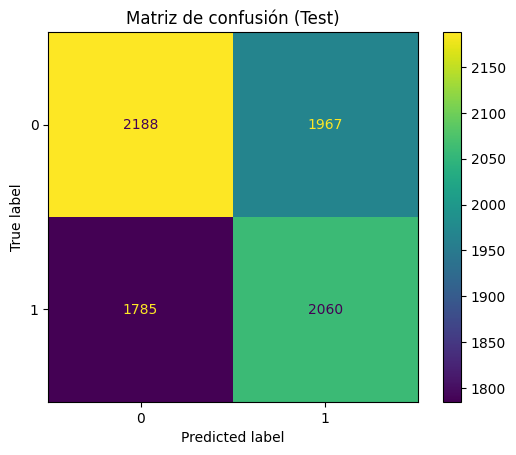

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format="d")
plt.title("Matriz de confusión (Test)")
plt.show()

**Análisis de la matriz de confusión:**

De las 8,000 muestras de prueba, el modelo acierta 2,188 verdaderos `Loss` y 2,060 verdaderos `Win`, pero se equivoca en 1,967 casos donde predijo `Win` y en realidad era `Loss` (falsos positivos), y en 1,785 casos donde predijo `Loss` y en realidad era `Win` (falsos negativos). Los dos tipos de error están en una proporción muy similar (1,967 vs. 1,785), esto es justamente el reflejo numérico del recall balanceado que se observó arriba: el modelo no tiene un sesgo fuerte hacia equivocarse más en una dirección que en la otra.

In [ ]:
# Extraemos el modelo final y el escalador para obtener coeficientes comparables
final_model = grid_lr.best_estimator_.named_steps['logreg']

coefs = pd.DataFrame({
    "feature": preprocesador.get_feature_names_out(),
    "coef": final_model.coef_.ravel()
}).sort_values("coef", ascending=False)

coefs.head(10)

,feature,coef
5,num__APM,0.059733
4,num__Screen_Brightness,0.018725
6,num__Heart_Rate_BPM,0.010338
7,num__HRV_Score,0.008304
11,cat__Game_Genre_Fighting,0.006590
12,cat__Game_Genre_MOBA,0.002952
10,cat__Game_Genre_FPS,-0.003217
13,remainder__Blue_Light_Filter,-0.003842
9,cat__Game_Genre_Battle Royale,-0.005702
1,num__PlayTime_Hours,-0.005790


**Análisis de los coeficientes:**

En una regresión logística, cada coeficiente indica qué tanto y en qué dirección influye una variable sobre la probabilidad de ganar: un coeficiente positivo empuja la predicción hacia `Win`, uno negativo la empuja hacia
`Loss`, y entre más lejos esté de cero, mayor es su influencia.

Al revisar los resultados, se confirma exactamente lo que ya se había visto en el EDA:

- `APM` tiene el coeficiente positivo más alto (0.060), a más acciones por minuto, mayor probabilidad de ganar.
- `Reaction_Time_ms` tiene el coeficiente negativo más fuerte (-0.083), a mayor tiempo de reacción, menor probabilidad de ganar.
- El resto de variables (`Screen_Brightness`, `Heart_Rate_BPM`, `HRV_Score`, las categorías de `Game_Genre`, `Blue_Light_Filter`, `PlayTime_Hours`, `Age`, `Sleep_Hours`, `Energy_Drinks`) tienen coeficientes muy cercanos a cero, es decir, aportan muy poco al modelo por sí solas.

Esto coincide con lo que ya se había observado en los boxplots del EDA, donde `APM` y `Reaction_Time_ms` eran las únicas variables con alguna diferencia visible entre partidas ganadas y perdidas, mientras que el resto se veía
prácticamente igual entre ambas clases. El modelo entrenado llega a una conclusión similar que el análisis exploratorio.

# Entrenamiento con SVM
Validación cruzada (10 folds)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report


pipeline_svm = Pipeline(steps=[
    ("preprocess", preprocesador),
    ("modelo", SVC(random_state=42, class_weight='balanced'))
])

param_grid_svm = [
    {'modelo__kernel': ['linear'], 'modelo__C': [0.1, 1, 10]},
    {'modelo__kernel': ['rbf'], 'modelo__C': [0.1, 1, 10], 'modelo__gamma': ['scale', 'auto']},
    {'modelo__kernel': ['poly'], 'modelo__C': [0.1, 1, 10], 'modelo__gamma': ['scale']}
]

cv = StratifiedKFold(n_splits=10, shuffle=False)

grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)

print("\nMejores hiperparámetros (SVM):", grid_svm.best_params_)
print("Mejor F1 promedio en validación cruzada (10 folds):", round(grid_svm.best_score_, 4))

y_pred_svm = grid_svm.predict(X_test)
print("\n--- Reporte de clasificación en el conjunto de prueba (SVM) ---")
print(classification_report(y_test, y_pred_svm, target_names=['Loss', 'Win']))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Mejores hiperparámetros (SVM): {'modelo__C': 0.1, 'modelo__gamma': 'scale', 'modelo__kernel': 'poly'}
Mejor F1 promedio en validación cruzada (10 folds): 0.5154

--- Reporte de clasificación en el conjunto de prueba (SVM) ---
              precision    recall  f1-score   support

        Loss       0.54      0.50      0.52      4155
         Win       0.50      0.54      0.52      3845

    accuracy                           0.52      8000
   macro avg       0.52      0.52      0.52      8000
weighted avg       0.52      0.52      0.52      8000



**Análisis:**

- Con `class_weight='balanced'` agregado, y evaluando las 120 combinaciones completas (12 candidatos × 10 folds), el mejor modelo usa kernel `poly` con `C=0.1` (`gamma='scale'`), con F1 promedio en validación cruzada de **0.5154**.
- En el conjunto de prueba: `Loss` obtiene precision=0.54, recall=0.50, F1=0.52; `Win` obtiene precision=0.50, recall=0.54, F1=0.52. El recall queda prácticamente parejo entre clases (0.50 vs. 0.54), muy similar al comportamiento que ya se había visto en la regresión logística (0.53/0.54).
- Accuracy (0.52) y F1 macro (0.52) quedan muy cerca de los de la regresión logística (0.53 en ambos casos). La diferencia entre los dos modelos es pequeña, refleja una diferencia entre lo que cada algoritmo logra capturar en los datos.

F1: 0.5189
Precision: 0.5007
Recall: 0.5384


<Figure size 640x480 with 0 Axes>

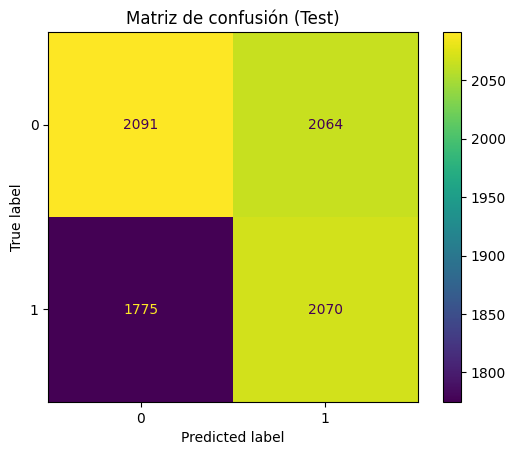

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure()
disp.plot(values_format="d")
plt.title("Matriz de confusión (Test)")
plt.show()

**Análisis de la matriz de confusión:**

Sobre el total de 8,000 muestras, el modelo acierta 4,161 (2,091 + 2,070), lo que da una accuracy de **0.52**.
Lo más relevante es que los dos tipos de error están casi perfectamente equilibrados (2,064 FP vs. 1,775 FN), el modelo no comete sistemáticamente más errores en una dirección que en la otra, resultado directo de haber
usado `class_weight='balanced'`. Esto es consistente con el recall parejo obtenido entre clases (recall Loss=0.50,
recall Win=0.54): antes de agregar `class_weight`, el modelo favorecía claramente una clase sobre la otra, y esa
asimetría ya no está presente.

# Comparación de modelos Regresión logística vs SVM

,Regresión Logística,SVM (kernel polinomial)
"F1 (CV, 10-fold)",0.525,0.515
Accuracy (test),0.531,0.520
Precision Loss,0.551,0.541
Recall Loss,0.527,0.503
F1 Loss,0.538,0.521
Precision Win,0.512,0.501
Recall Win,0.536,0.538
F1 Win,0.523,0.519
F1 macro (test),0.531,0.520


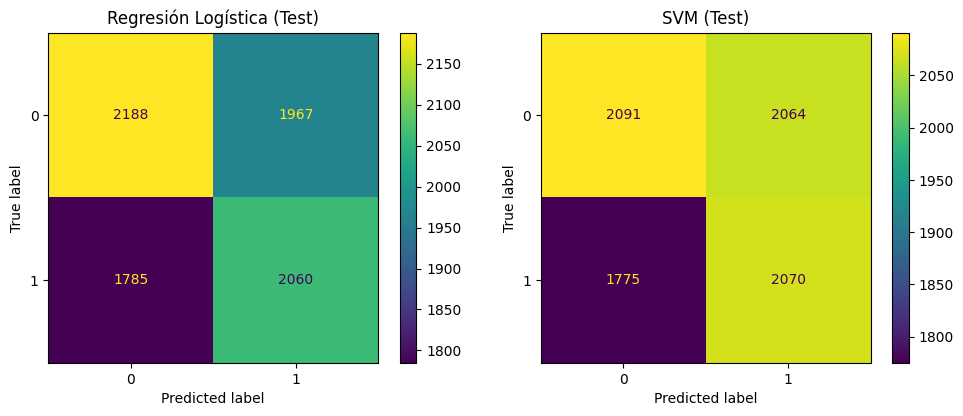

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metricas_modelo(y_true, y_pred, cv_f1):
    return {
        'F1 (CV, 10-fold)': cv_f1,
        'Accuracy (test)': accuracy_score(y_true, y_pred),
        'Precision Loss': precision_score(y_true, y_pred, pos_label=0),
        'Recall Loss': recall_score(y_true, y_pred, pos_label=0),
        'F1 Loss': f1_score(y_true, y_pred, pos_label=0),
        'Precision Win': precision_score(y_true, y_pred, pos_label=1),
        'Recall Win': recall_score(y_true, y_pred, pos_label=1),
        'F1 Win': f1_score(y_true, y_pred, pos_label=1),
        'F1 macro (test)': f1_score(y_true, y_pred, average='macro'),
    }

resultados = pd.DataFrame({
    'Regresión Logística': metricas_modelo(y_test, y_pred_lr, grid_lr.best_score_),
    'SVM (kernel polinomial)': metricas_modelo(y_test, y_pred_svm, grid_svm.best_score_),
}).round(3)

display(resultados)

# Matriz de confusión - Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Matriz de confusión - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Regresión Logística
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(values_format="d", ax=axes[0])
axes[0].set_title("Regresión Logística (Test)")

# SVM
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(values_format="d", ax=axes[1])
axes[1].set_title("SVM (Test)")

plt.tight_layout()
print()
plt.show()


- **Falsos positivos** (el modelo predice `Win` pero el resultado real fue `Loss`): 1,967 casos en Regresión Logística (47.3% de todos los `Loss` reales) y 2,064 en SVM (49.7% de los `Loss` reales). Es decir, casi la mitad de las veces que un jugador realmente perdió, el modelo le hubiera dicho que iba a ganar.

- **Falsos negativos** (predice `Loss` pero el resultado real fue `Win`): 1,785 en Regresión Logística (46.4% de los `Win` reales) y 1,775 en SVM (46.2%). Prácticamente la misma proporción que los falsos positivos en cada modelo, lo cual es una señal de que el error no está sesgado hacia un solo tipo de equivocación, sino repartido casi por igual entre ambas clases.

- **SVM comete un poco más falsos positivos que Regresión Logística** (49.7% vs 47.3%), es decir, es ligeramente más propenso a predecir `Win` cuando en realidad el jugador pierde.

- Que las tasas de error ronden el **46-50% en ambas clases y en ambos modelos** es prácticamente el comportamiento de una moneda al aire: La capacidad predictiva real sigue siendo baja en ambos modelos.

## **Conclusiones finales**




1. **La señal predictiva disponible en el dataset es débil.** El EDA y los coeficientes del modelo final coinciden en que solo `APM` y `Reaction_Time_ms` muestran alguna diferencia entre partidas ganadas y perdidas; el resto de variables biométricas (`Age`, `Sleep_Hours`, `Heart_Rate_BPM`, `HRV_Score`, etc.) aportan casi nada de forma individual. Esta coherencia entre el análisis exploratorio y el modelo entrenado confirma que no es una limitación del algoritmo, sino de la información disponible.


2. **La Regresión Logística es la opción más viable entre los dos modelos. (teniendo en cuenta que no predice correctamente)** Ya que tiene un leve mejor desempeño, es más rápido de entrenar y sus coeficientes son directamente interpretables.

3. **El resultado de una partida probablemente depende de factores no incluidos en este dataset** (nivel del rival, composición del equipo, estrategia en el juego) que del estado biométrico del jugador antes de jugar. Una línea de trabajo futuro sería incorporar variables adicionales relacionadas con el contexto de la partida.

In [ ]:
# Si queremos evaluar un jugador con características específicas
jugador = pd.DataFrame({
    "Age": [20],
    "PlayTime_Hours": [80],
    "Sleep_Hours": [8],
    "Energy_Drinks": [2],
    "Screen_Brightness": [60],
    "APM": [563],
    "Heart_Rate_BPM": [70],
    "HRV_Score": [50],
    "Reaction_Time_ms": [1],
    "Game_Genre": ["Battle Royale"],
    "Blue_Light_Filter": [0]
})

prediccion_lr = grid_lr.best_estimator_.predict(jugador)
print("Predicción Regresión Logística: ", prediccion_lr)

prediccion_svm = grid_svm.best_estimator_.predict(jugador)
print("Predicción SVM: ", prediccion_svm)

Predicción Regresión Logística:  [1]
Predicción SVM:  [1]
